In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("titanic.csv")

In [3]:
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [4]:
print("Dataset shape:", df.shape)

Dataset shape: (891, 15)


In [5]:
print(df.columns)

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [7]:
df.describe

<bound method NDFrame.describe of      survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0           0       3    male  22.0      1      0   7.2500        S   Third   
1           1       1  female  38.0      1      0  71.2833        C   First   
2           1       3  female  26.0      0      0   7.9250        S   Third   
3           1       1  female  35.0      1      0  53.1000        S   First   
4           0       3    male  35.0      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
886         0       2    male  27.0      0      0  13.0000        S  Second   
887         1       1  female  19.0      0      0  30.0000        S   First   
888         0       3  female   NaN      1      2  23.4500        S   Third   
889         1       1    male  26.0      0      0  30.0000        C   First   
890         0       3    male  32.0      0      0   7.7500        Q   Third   

       who  adult

In [8]:
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [9]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64


In [10]:
df_cleaned = df.copy()

In [11]:
df_cleaned["age"] = df_cleaned["age"].fillna(
    df_cleaned["age"].median()
)

In [12]:
df_cleaned["embarked"] = df_cleaned["embarked"].fillna(
    df_cleaned["embarked"].mode()[0]
)

df_cleaned["embark_town"] = df_cleaned["embark_town"].fillna(
    df_cleaned["embark_town"].mode()[0]
)

In [13]:
df_cleaned = df_cleaned.drop(columns=["deck"])

In [14]:
print(df_cleaned.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [15]:
five_point_summary = df_cleaned["fare"].describe()[
    ["min", "25%", "50%", "75%", "max"]
]

print("Five-number summary of Fare:")
print(five_point_summary)

Five-number summary of Fare:
min      0.0000
25%      7.9104
50%     14.4542
75%     31.0000
max    512.3292
Name: fare, dtype: float64


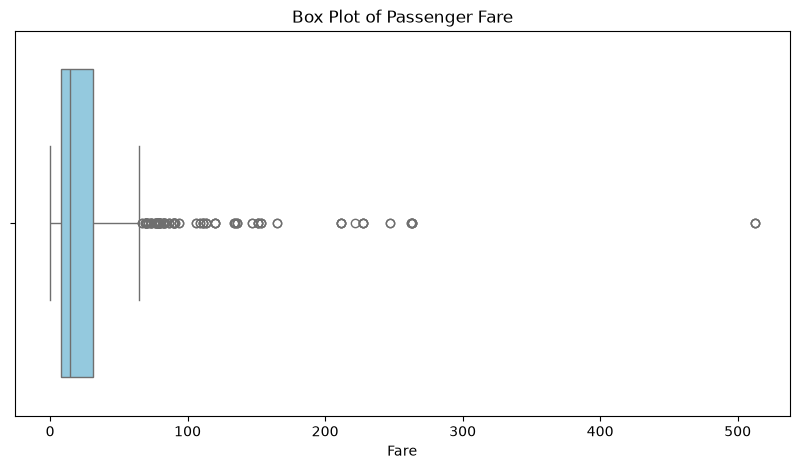

In [16]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df_cleaned["fare"],
    color="skyblue"
)

plt.title("Box Plot of Passenger Fare")
plt.xlabel("Fare")
plt.show()

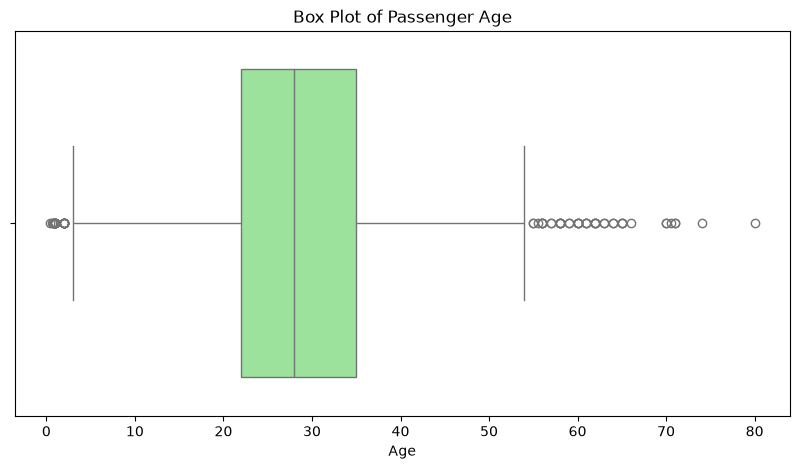

In [17]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df_cleaned["age"],
    color="lightgreen"
)

plt.title("Box Plot of Passenger Age")
plt.xlabel("Age")
plt.show()

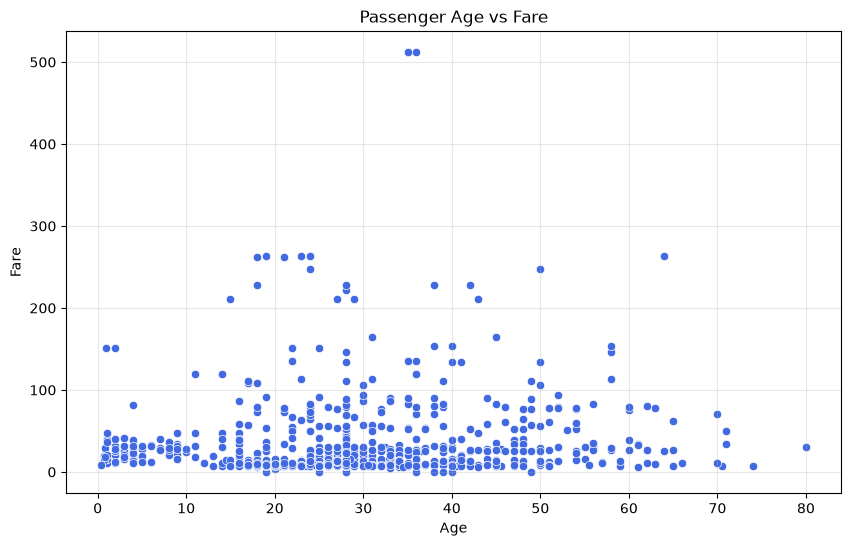

In [18]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_cleaned,
    x="age",
    y="fare",
    color="royalblue"
)

plt.title("Passenger Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.grid(alpha=0.3)
plt.show()

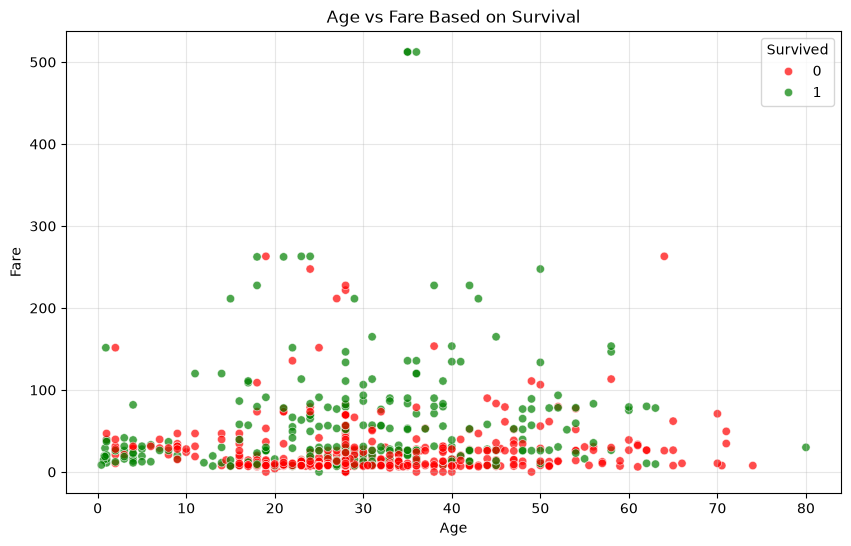

In [19]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_cleaned,
    x="age",
    y="fare",
    hue="survived",
    palette={0: "red", 1: "green"},
    alpha=0.7
)

plt.title("Age vs Fare Based on Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.legend(title="Survived")
plt.grid(alpha=0.3)
plt.show()

In [20]:
numerical_df = df_cleaned.select_dtypes(include="number")

numerical_df.head()

,survived,pclass,age,sibsp,parch,fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,0,3,35.0,0,0,8.0500


In [21]:
correlation_matrix = numerical_df.corr()

print(correlation_matrix)

          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.338481 -0.064910 -0.035322  0.081629  0.257307
pclass   -0.338481  1.000000 -0.339898  0.083081  0.018443 -0.549500
age      -0.064910 -0.339898  1.000000 -0.233296 -0.172482  0.096688
sibsp    -0.035322  0.083081 -0.233296  1.000000  0.414838  0.159651
parch     0.081629  0.018443 -0.172482  0.414838  1.000000  0.216225
fare      0.257307 -0.549500  0.096688  0.159651  0.216225  1.000000


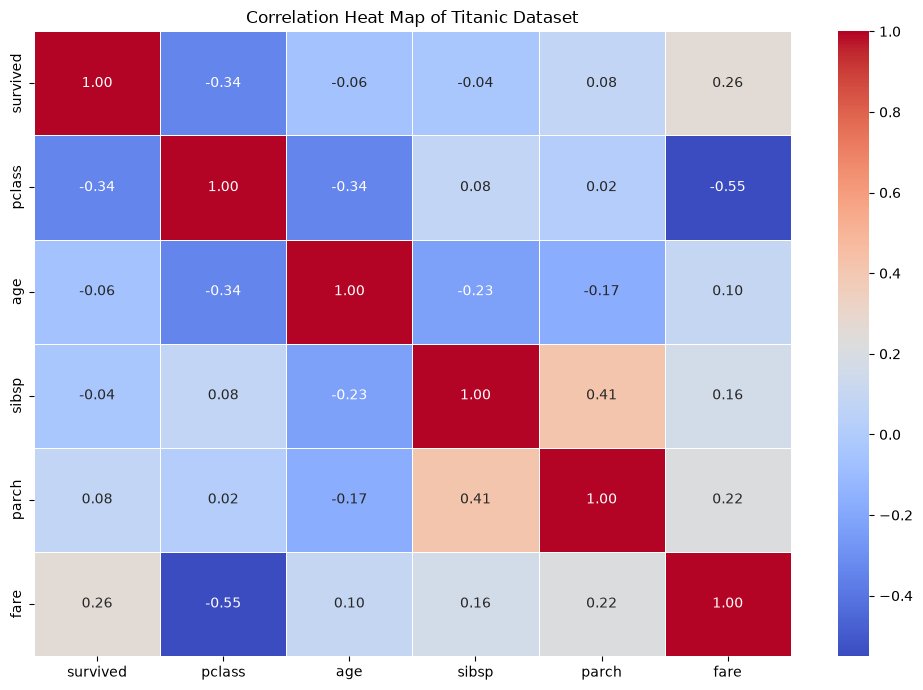

In [22]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heat Map of Titanic Dataset")
plt.tight_layout()
plt.show()